In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid')

In [3]:
# local imports
import cache
import embedding
import evaluation
import preprocessing
import visualization

# Problem Statement

French caselaw search engines surface relevant decisions across **4 legal domains**: Civil (`civ`), Commercial (`com`), Criminal (`crim`), and Social (`soc`). Automatically routing decisions to the right domain is needed for accurate search and recommendation.

**Task**: multi-class classification of French court decisions into one of 4 legal domains, trained on `cour_de_cassation` (France's highest court) and evaluated on held-out lower courts.

**Key challenges**:
* **Template overfitting**: cassation decisions follow a standardised format, so a naive model may classify by structure rather than legal vocabulary, and fail on OOD inputs
* **Same-source test set is not enough**: OOS evaluation on a held-out cassation split overstates real-world performance; OOD evaluation on different court types (`tribunal_judiciaire`, `cour_d_appel`) is the real test
* **Class imbalance**: up to 3× between majority (`civ`) and minority (`com`, `crim`) classes
* **French NLP**: morphologically rich language — `licencier`/`licenciement` carry the same signal; char n-grams and CamemBERT handle this better than word-level tokenisation

# Evaluation Metrics

## OOS Evaluation

* Class imbalance -> `accuracy` loses meaning (majority class = 41% accuracy)
* Search Engine context -> FN are more costly than FP (worse to miss appropriate documents than showing wrong ones)
* But, only looking at `precision` or `recall` would only be one side of the story
* F1 wouldn't embed that FN are more costly than FP. Chosing F2 instead to prioritize recall over precision
* **Primary Metric = Macro F2**, with equal weights among classes to force model to learn about minority classes `class_weight='balanced'`
* Secondary metrics: Macro PR-AUC and per-class F2 score

## OOD Evaluation
* Other jurisdiction as OOD data:
  - **Training**: `cour_de_cassation`: highest court, structured chamber labels, single-label matches
  - **OOD**: `tribunal_judiciaire` + `cour_d_appel`: different court level, different writing style and document length
* Chamber-name matching (contains `soc`/`civ`/`crim`/`com`, exactly 1 match) ensures clean labels across all splits
* OOD gap measures how well legal vocabulary generalises across courts

---

# Data Preprocessing

## Data Loading/Processing

In [4]:
# Load full HF dataset — downloads once, then reads from parquet cache
raw = cache.load_or_run(
    "hf_jurisprudence.parquet",
    lambda: preprocessing.load_data(
        court_types=["cour_de_cassation", "cour_d_appel", "tribunal_judiciaire"],
        drop_uncategorized=True,
    )
)

# parse html and compute length features
raw["clean_text"] = preprocessing.parse_html(raw["text"])
raw["clean_char_count"] = raw["clean_text"].str.len()
raw["clean_word_count"] = raw["clean_text"].str.count(" ")

# main dataset: cour de cassation
df = raw[raw["court_type"] == "cour_de_cassation"].copy()
# OOD data: tribunal judiciaire + cour d'appel
ood_df = raw[raw["court_type"] != "cour_de_cassation"].copy()

print(f"Main dataset (cour de cassation): {len(df):,} rows")
print(f"OOD dataset (other courts): {len(ood_df):,} rows")

# delete raw to save memory
del raw

df.head(2)

[cache] loaded /Users/glangq/Desktop/codebase/doctrine/cache/hf_jurisprudence.parquet
Main dataset (cour de cassation): 535,595 rows
OOD dataset (other courts): 141,622 rows
CPU times: user 2min 46s, sys: 35.9 s, total: 3min 22s
Wall time: 4min 6s


,text,chamber,label,court_type,clean_text,clean_char_count,clean_word_count
4b93ee02-a849-4ef8-ac8f-6d86ea359919,"ANNUALTION, sur le pourvoi du sieur Y..., d'un...",Première chambre civile,civ,cour_de_cassation,"ANNUALTION, sur le pourvoi du sieur Y..., d'un...",3034,501
e6ce05cc-6ba3-4f65-98ae-75bd5544b079,MOYENS: \n\n\n Pourvoi en cassation du sieur Y...,Première chambre civile,civ,cour_de_cassation,MOYENS: Pourvoi en cassation du sieur Y... pou...,2839,490


## Data Filtering

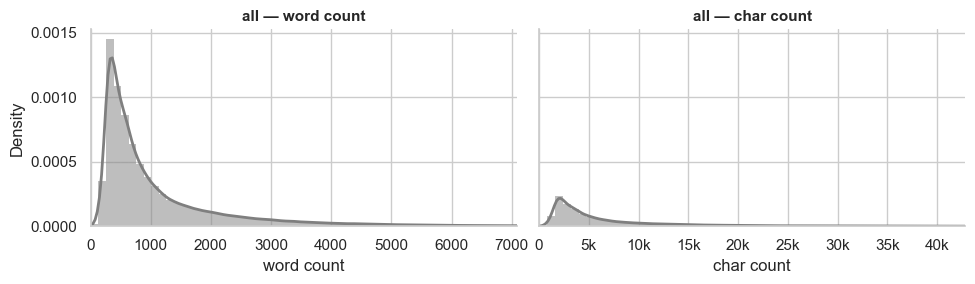

In [5]:
visualization.plot_length_distributions(df["clean_word_count"], df["clean_char_count"])

In [6]:
empty = df["clean_word_count"].eq(0)
too_short = df["clean_word_count"].lt(100)

print(f"Empty documents: {empty.sum():.0f} ({empty.mean():.2%})")
print(f"Documents too short (<100 words): {too_short.sum():.0f} ({too_short.mean():.2%})")

df = df[~too_short]

# Apply same filter to OOD data
ood_too_short = ood_df["clean_word_count"].lt(100)
print(f"\nOOD documents too short: {ood_too_short.sum():.0f} ({ood_too_short.mean():.2%})")
ood_df = ood_df[~ood_too_short]

Empty documents: 0 (0.00%)
Documents too short (<100 words): 306 (0.06%)

OOD documents too short: 8 (0.01%)


## Class Imbalance

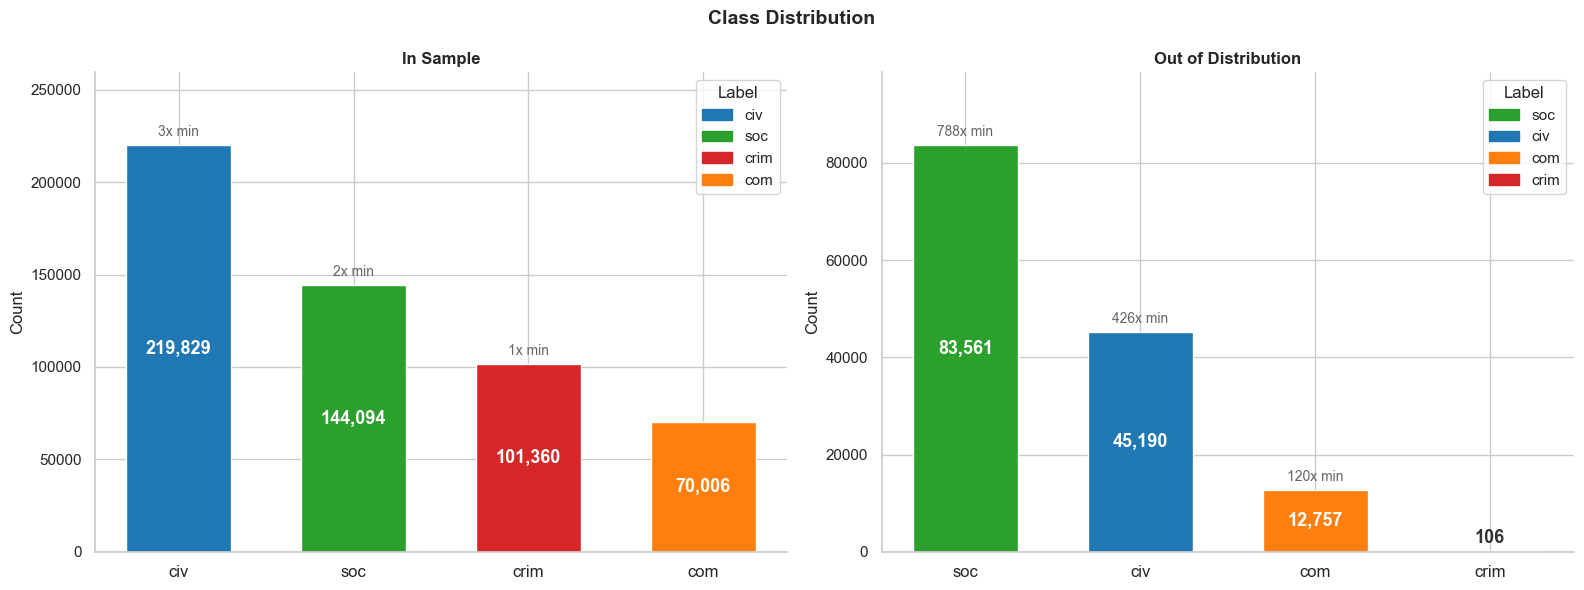

In [7]:
visualization.plot_class_imbalance(df["label"], ood_df["label"])

* Some class imbalance (3x between min/max). Minority classes: crim/com
* Justifies stratified train/test sampling and `class_weight='balanced'` in classifiers
* Difficulty to label `crim` class in OOD. Assuming most of the class is hidden by generic chamber names such as `7ème chambre`. 

## Train/Test Split

* Class imbalance => stratified split

In [8]:
train, test = preprocessing.stratified_split(df, class_col="label", test_pct=0.2)

* Ensure train/test indeed maintain class imbalance

In [9]:
visualization.stratified_split_table(df, train, test)

,all,train,test
label,,,
civ,41.07%,41.07%,41.07%
com,13.08%,13.08%,13.08%
crim,18.94%,18.94%,18.94%
soc,26.92%,26.92%,26.92%


## EDA: word/char length distribution per class

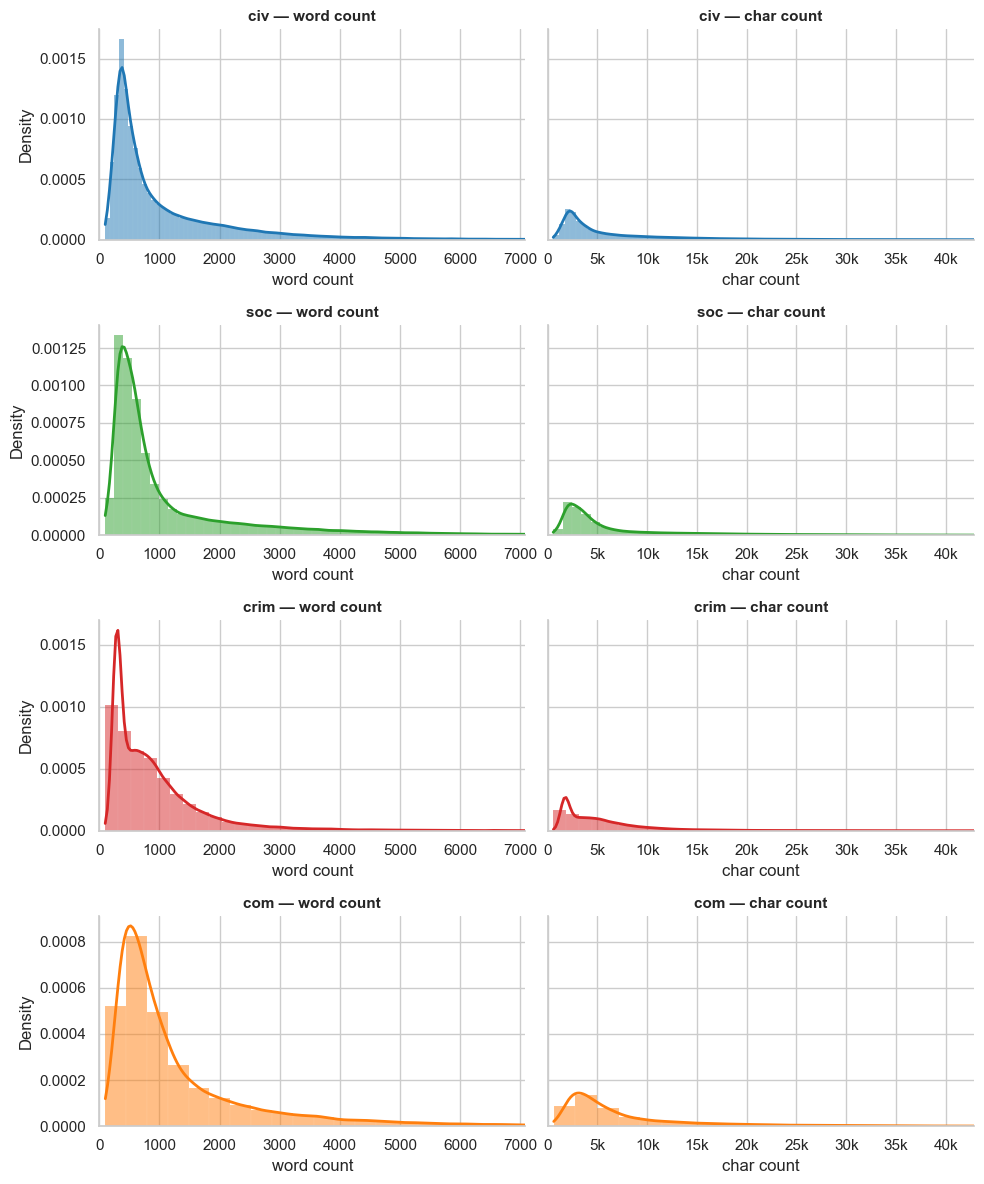

In [10]:
visualization.plot_length_distributions(
    df["clean_word_count"], 
    df["clean_char_count"],
    groupby=df["label"]
)

## TF-IDF Embedding

In [11]:
french_stop_words = preprocessing.load_word_list("french_stop_words.txt")

word_tfidf = TfidfVectorizer(
    analyzer="word", 
    # unigrams-only for fair comparison between NB/Logit
    ngram_range=(1, 1),  
    #  drop too common terms
    max_df=0.95,   
    #  drop too rare terms
    min_df=50,  
    # ignore numbers
    token_pattern=r"(?u)\b[a-zA-ZÀ-ÿ]{3,}\b",  
    # stop words (a, as, ai, est, ...)
    stop_words=french_stop_words,
)

In [12]:
word_tfidf_fit = cache.load_or_run(
    "word_tfidf_embedding.pkl",
    lambda: word_tfidf.fit(train["clean_text"])
)
print(f"Word TF-IDF dimensionality (train-only): {len(word_tfidf_fit.vocabulary_):,.0f}")

[cache] loaded /Users/glangq/Desktop/codebase/doctrine/cache/word_tfidf_embedding.pkl
Word TF-IDF dimensionality (train-only): 32,537
CPU times: user 33.4 ms, sys: 1.79 ms, total: 35.2 ms
Wall time: 36.3 ms


In [13]:
top_tfidf_per_class = cache.load_or_run(
    "top_tfidf_per_class.parquet",
    lambda: visualization.top_tfidf_per_class(
        df, 
        "clean_text", 
        "label", 
        n=15, 
        vec=word_tfidf
    )
)
top_tfidf_per_class

[cache] loaded /Users/glangq/Desktop/codebase/doctrine/cache/top_tfidf_per_class.parquet
CPU times: user 1.83 ms, sys: 10.4 ms, total: 12.3 ms
Wall time: 48.6 ms


,civ,com,crim,soc
0,cassation,cassation,président,travail
1,civile,moyen,conseiller,cassation
2,moyen,banque,pénale,conseiller
3,conseiller,conseiller,criminelle,salarié
4,président,contrat,publique,licenciement
5,audience,commerciale,audience,employeur
6,publique,civile,moyen,sociale
7,parties,président,instruction,moyen
8,demeurant,selon,admission,contrat
9,droit,parties,greffier,président


Top TF-IDF terms per class from Cour de cassation — expect cleaner legal vocabulary signals than cour d'appel:
* **SOC**: `licenciement`, `employeur`, `salarié`
* **CRIM**: `pénale`, `criminelle`, `admission`
* **COM**: `commerciale`, `créance`
* **CIV**: `civile`, `publique`

---

# Modeling Approach

### Tokenization
* Lexicographical task -> start with TF-IDF metric, then BERT-type embedding
* TF-IDF = frequency distributions of words/tokens per class, but penalize commonality accross classes (e.g. `jugement` or `cour` = no information)

### Baselines
* Dummy and Naive Bayes, standard but very brittle in this context
* Expect these baselines to be easily beaten by more sophisticated models

### Logit
* Great model for classification task here, given dimensionality
* Handles class imbalance naturally
* Allow tuning of regularization coef, especially for TF-IDF embedding (highly dimensional)

### Deep Learning
* BERT fine tuning for classification task
* Would give best result,
* Allow eventual stack of TF-IDF and lexical embedding features
---

# Dummy classifier

In [14]:
dummy_clf = DummyClassifier(strategy='stratified', random_state=42)
dummy_clf.fit(train['clean_text'], train['label'])
dummy = evaluation.eval_multiclass(dummy_clf, test, ood_df=ood_df, beta=2)
dummy

,precision,recall,f2,pr_auc
civ,41.0%,41.0%,41.0%,41.0%
com,12.8%,12.8%,12.8%,13.0%
crim,18.8%,18.9%,18.9%,18.9%
soc,26.9%,26.8%,26.8%,26.9%
macro,24.9%,24.9%,24.9%,25.0%
tr/pr,civ,com,crim,soc
civ,"18,010","5,733","8,327","11,896"
com,"5,758","1,795","2,757","3,691"
crim,"8,281","2,718","3,836","5,437"
soc,"11,907","3,732","5,460","7,720"


- **Macro F2 ~25%** is the floor performance for more sophisticated models
- `stratified` strategy gives better performance than `most_frequent`

---

# TF-IDF + Naive Bayes

In [15]:
def get_nb_result() -> evaluation.EvalMulticlassResult:
    naive_bayes_clf = Pipeline([
        ('tfidf', clone(word_tfidf)),
        ('clf',   MultinomialNB()),
    ])
    naive_bayes_clf.fit(train['clean_text'], train['label'])
    naive_bayes = evaluation.eval_multiclass(naive_bayes_clf, test, ood_df=ood_df, beta=2)
    return naive_bayes

naive_bayes = cache.load_or_run("tfidf_naive_bayes.pkl", get_nb_result)
naive_bayes

[cache] loaded /Users/glangq/Desktop/codebase/doctrine/cache/tfidf_naive_bayes.pkl
CPU times: user 31.6 ms, sys: 1.67 ms, total: 33.3 ms
Wall time: 34.5 ms


,precision,recall,f2,pr_auc
civ,94.6%,93.1%,93.4%,98.7%
com,88.5%,91.9%,91.2%,96.2%
crim,98.3%,96.2%,96.7%,99.6%
soc,94.2%,96.1%,95.7%,99.0%
macro,93.9%,94.3%,94.2%,98.4%
tr/pr,civ,com,crim,soc
civ,"40,947","1,341",251,"1,427"
com,988,"12,860",45,108
crim,350,231,"19,511",180
soc,991,96,32,"27,700"


In [16]:
visualization.top_nb_features(naive_bayes.model, n=10)

,civ,com,crim,soc
0,cassation,commerciale,criminelle,travail
1,civile,cassation,pénale,sociale
2,moyen,banque,cassation,salarié
3,conseiller,financière,conseiller,licenciement
4,président,moyen,président,employeur
5,rendu,économique,instruction,cassation
6,parties,commerce,contre,contrat
7,audience,créance,mémoire,conseiller
8,publique,conseiller,date,prud
9,motifs,selon,publique,moyen


**Pros**
* Macro F2 much higher than dummy classifier
* Super fast training and inference
* Word boundary per class seems in line with what we expected above

**Cons**
* Independence assumption made by NB fails — legal terms like `tribunal` and `grande instance` co-occur systematically
* No class imbalance handling → model doesn't learn about minority classes that well (esp. `com` class)

---

# TF-IDF + Logit (word-based)

In [17]:
def get_word_logit_result() -> evaluation.EvalMulticlassResult:
    word_logit_clf = Pipeline([
        ('tfidf', clone(word_tfidf)),
        ('clf',   LogisticRegression(C=1, class_weight='balanced', max_iter=1000, random_state=42)),
    ])
    word_logit_clf.fit(train['clean_text'], train['label'])
    word_logit = evaluation.eval_multiclass(word_logit_clf, test, ood_df=ood_df, beta=2)
    return word_logit

word_logit = cache.load_or_run("word_tfidf_logit.pkl", get_word_logit_result)
word_logit

[cache] loaded /Users/glangq/Desktop/codebase/doctrine/cache/word_tfidf_logit.pkl


,precision,recall,f2,pr_auc
civ,98.8%,97.5%,97.8%,99.8%
com,94.4%,98.3%,97.5%,99.4%
crim,99.9%,99.8%,99.8%,100.0%
soc,98.8%,98.8%,98.8%,99.9%
macro,98.0%,98.6%,98.5%,99.8%
tr/pr,civ,com,crim,soc
civ,"42,882",765,18,301
com,212,"13,760",4,25
crim,13,11,"20,240",8
soc,286,42,4,"28,487"


In [18]:
visualization.top_logreg_features(word_logit.model, n=10)

,civ,com,crim,soc
0,civile,commerciale,criminelle,sociale
1,deuxième,économique,pénale,prud
2,civ,financière,violation,travail
3,sécurité,selon,prévenu,employeur
4,deuxieme,mouillard,partie,salarié
5,première,financiere,prevenu,licenciement
6,degre,economique,coupable,soc
7,batut,comm,civiles,homale
8,drouillat,defere,date,grief
9,assigne,branches,manque,hommes


**Pros**
* Does not assume independence of word occurrence
* Handles class imbalance naturally → model learns minority classes (Commercial/Crime)
* **Strong OOS performance, 98.5% macro F2**, 4 points more than NB classifier
* Per-class, we still see some confusion between `civ` and `com` classes

**Cons**
* Cassation chamber names (`chambre commerciale`, `chambre sociale`) may leak into the vocabulary → model learns chamber-naming patterns rather than legal vocabulary
* Word-analyzer treats `licencier` and `licenciement` as different words → signal loss, especially important in inflected languages (French/Italian/Spanish)
* **OOD gap**: Macro F2 from 98.5% OOS to 55% OOD. Gap is expected: other courts uses different structural cues and more varied cases

---

# TF-IDF + Logit (char-based)

In [19]:
char_tfidf = TfidfVectorizer(
    analyzer="char_wb", 
    ngram_range=(3, 5),  # 3-5 chars long
    #  drop too common terms
    max_df=0.9,   
    #  drop too rare terms
    min_df=100,  
    # ignore numbers, otherwise dates in crim class
    token_pattern=r"(?u)\b[a-zA-ZÀ-ÿ]{3,}\b",  
)

In [20]:
def get_char_logit_result() -> evaluation.EvalMulticlassResult:
    char_logit_clf = Pipeline([
        ('tfidf', clone(char_tfidf)),
        ('clf',   LogisticRegression(C=1, class_weight='balanced', max_iter=1000, random_state=42)),
    ])
    char_logit_clf.fit(train['clean_text'], train['label'])
    char_logit = evaluation.eval_multiclass(
        char_logit_clf, 
        test, 
        ood_df=ood_df, 
        beta=2
    )
    return char_logit

char_logit = cache.load_or_run("char_tfidf_logit.pkl", get_char_logit_result)

vocab_len = len(char_logit.model[0].vocabulary_)
print(f"Char TF-IDF dimensionality (train-only): {vocab_len:,.0f}")

char_logit

[cache] loaded /Users/glangq/Desktop/codebase/doctrine/cache/char_tfidf_logit.pkl
Char TF-IDF dimensionality (train-only): 141,739


,precision,recall,f2,pr_auc
civ,99.0%,97.6%,97.9%,99.9%
com,94.2%,98.3%,97.5%,99.5%
crim,99.9%,99.8%,99.8%,100.0%
soc,98.9%,98.9%,98.9%,99.9%
macro,98.0%,98.7%,98.5%,99.8%
tr/pr,civ,com,crim,soc
civ,"42,905",768,19,274
com,202,"13,765",3,31
crim,14,12,"20,234",12
soc,237,62,7,"28,513"


**Pros**
* More robust than word-tfidf: char n-grams naturally handle morphological variants (`licen` covers `licenciement`/`licencier`)
* Better OOD performance than word-tfidf model, shows robustness
  
**Cons**
* 140k dimensions: slower for training and inference
* `civ`/`com` confusion remains: character-level features don't resolve semantic overlap between the two domains
* OOD performance is still a meaningful gap to reduce

---

## CamemBERT Embeddings + Logit

In [21]:
device = embedding.get_device()

print(f"device: {device}")

tokenizer, frozen_bert_model = embedding.load_model("camembert-base", device)

device: mps


Loading weights: 100%|████████████████████████████████████████████████| 199/199 [00:00<00:00, 6499.86it/s]
[transformers] CamembertModel LOAD REPORT from: camembert-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [22]:
embeddings_kwargs = dict(
    tokenizer=tokenizer,
    model=frozen_bert_model,
    device=device,
    max_length=128,
    batch_size=128,
    progress=True
)
embedding_path = "embeddings.npz"
embedding_path_ood = "embeddings_ood.npz"

embeddings = cache.load_or_run(
    embedding_path,
    lambda: embedding.embed(df["clean_text"].tolist(), **embedding_kwargs),
    index=df.index,
)
embeddings_ood = cache.load_or_run(
    embedding_path_ood,
    lambda: embedding.embed(ood_df["clean_text"].tolist(), **embedding_kwargs),
    index=ood_df.index,
)

[cache] loaded /Users/glangq/Desktop/codebase/doctrine/cache/embeddings.npz
[cache] loaded /Users/glangq/Desktop/codebase/doctrine/cache/embeddings_ood.npz
CPU times: user 755 ms, sys: 1.08 s, total: 1.83 s
Wall time: 2.33 s


In [23]:
def get_frozen_bert_result() -> evaluation.EvalMulticlassResult:

    cache_dir = cache.CACHE_DIR
    X_train_emb = cache.load_or_run(embedding_path, fn=None, index=train.index)
    X_test_emb  = cache.load_or_run(embedding_path, fn=None, index=test.index)
    X_ood_emb = cache.load_or_run(embedding_path_ood, fn=None, index=ood_df.index)
    
    bert_logit_clf = LogisticRegression(C=1, class_weight="balanced", max_iter=1000, random_state=42)
    bert_logit_clf.fit(X_train_emb, train["label"])
    
    frozen_bert = evaluation.eval_multiclass(
        bert_logit_clf, 
        test, 
        ood_df=ood_df, 
        X=X_test_emb, 
        X_ood=X_ood_emb,
        tokenizer=tokenizer,
        encoder=frozen_bert_model,
        beta=2,
    )

    return frozen_bert

frozen_bert = cache.load_or_run("frozen_bert_logit.pkl", get_frozen_bert_result)

frozen_bert

[cache] loaded /Users/glangq/Desktop/codebase/doctrine/cache/frozen_bert_logit.pkl
CPU times: user 1.06 ms, sys: 2.2 ms, total: 3.27 ms
Wall time: 8.74 ms


,precision,recall,f2,pr_auc
civ,97.2%,93.9%,94.5%,99.2%
com,86.8%,94.7%,93.0%,97.2%
crim,99.6%,99.6%,99.6%,100.0%
soc,95.5%,96.2%,96.0%,99.1%
macro,94.8%,96.1%,95.8%,98.9%
tr/pr,civ,com,crim,soc
civ,"41,281","1,577",43,"1,065"
com,514,"13,257",9,221
crim,38,22,"20,181",31
soc,657,420,23,"27,719"


**Pros**
* Learns semantic representations rather than word statistics → expect to generalise better across court hierarchies

**Cons**
* OOS performance is below TF-IDF logit (95.4% vs 98.5%)
* OOD performance is much poorer than TF-IDF logit (36.6% vs 57.7%)
* Embedding/Infering is slower than with TF-IDF models
* Better understanding of legal vocabulary should close the gap: fine-tuning CamemBERT on cassation data is expected to over perform TF-IDF models. Natural next step.

---

# Models Summary

In [24]:
visualization.summary_table(
    dummy=dummy,
    naive_bayes=naive_bayes,
    word_logit=word_logit,
    char_logit=char_logit,
    frozen_bert=frozen_bert,
)

CPU times: user 2.47 ms, sys: 1.35 ms, total: 3.82 ms
Wall time: 6.78 ms


,Macro F2,Min F2,OOD F2,PR-AUC,Inference ms
dummy,24.9%,12.8%,20.5%,25.0%,0.2 ms
naive_bayes,94.2%,91.2%,49.0%,98.4%,0.4 ms
word_logit,98.5%,97.5%,55.1%,99.8%,0.4 ms
char_logit,98.5%,97.5%,59.5%,99.8%,3.3 ms
frozen_bert,95.8%,93.0%,35.3%,98.9%,38.3 ms


* All non-dummy models clear **94%+ OOS Macro F2**, confirming legal vocabulary signals are strong within cassation data
* `word_logit` and `char_logit` tie OOS at **98.5% F2** — TF-IDF logit saturates in-sample performance
* **OOD is where models diverge**: `char_logit` leads at **59.5%**, `word_logit` at 55.1%, `naive_bayes` at 49.0%, `frozen_bert` at only 35.3%
* Char n-grams confirm their robustness advantage: smallest OOD gap (−39pp vs −43pp for word), as subword features generalise better across court types
* **`frozen_bert` suffers the largest OOD drop** (−60pp): the CLS embedding encodes cassation-specific structure rather than legal semantics — consistent with the template overfitting hypothesis; fine-tuning is the natural fix
* Inference: `word_logit` (0.42ms) and `naive_bayes` (0.43ms) are fastest production-grade options; `char_logit` is 7× slower (3.3ms) but still viable; `frozen_bert` at 38ms would require batching + ONNX export for production
* **`char_logit` is the strongest baseline**: best OOD generalisation, near-perfect OOS, acceptable latency

---

# Next steps

* Error Analysis: inspect which documents are misclassified
  - short documents?
  - ambiguous CIV/COM?
* Fine-tune CamemBERT with a classification head on cassation data
  - Would learn domain vocabulary without chamber-name shortcuts
  - Expecting better OOD generalisation than frozen BERT + Logit
* Analyse OOD by court type (`tribunal_judiciaire` vs `cour_d_appel` separately)


---